# Eval-suite latency and token usage

Compare wall-clock time and tokens generated across the 5 OOD test sets (wildguardmix, aegis, toxic-chat, openai-moderation, xstest) for our headline safety classifiers.

**Models compared**
- *WildGuard 7B* (prior-work, classification)
- *NVIDIA Nemotron Content-Safety 4B* (prior-work, reasoning)
- *GuardReasoner 8B* (prior-work, reasoning)
- *OpenAI gpt-oss-safeguard 120B* (prior-work, reasoning)
- *Llama-3.1-8B SFT generation* (our own fine-tune)
- *Gemma-3-12B Distill* (best distilled model: gpt-oss-120b teacher → gemma-3-12b student, human_intent, lr=2e-5)

**Data source.** Per-(dataset, condition) timing was backfilled from W&B via `scripts/backfill_eval_timing.py` into local `*_suite_summary.json` files under `data/safety_experiment/`. Future eval runs save the same JSON directly (see `scripts/eval_safety_classifier.py`), so this notebook never needs to talk to W&B.

**Caveat.** Eval used vLLM continuous batching: the full test set is submitted in one `llm.generate()` call. The numbers here are *wall-clock time to finish the entire OOD suite* on the SLURM-allocated GPU. They do not reflect single-request latency. Hardware-mix matters too: different runs may have used different GPUs (RTX PRO 6000 vs H100), so treat as indicative rather than head-to-head.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root relative to this notebook (notebooks/baselines/).
REPO = Path('.').resolve().parents[1]
DATA = REPO / 'data' / 'safety_experiment'

# OOD test sets in scope. annotated-intents is in-domain and excluded from the suite total.
OOD_DATASETS = ['wildguardmix', 'aegis', 'toxic-chat', 'openai-moderation', 'xstest']

MODELS = [
    {
        'label': 'WildGuard (7B)',
        'kind': 'classification',
        'path': DATA / 'allenai_wildguard_wildguard_classification_suite_summary.json',
    },
    {
        'label': 'Nemotron Safety (4B)',
        'kind': 'classification (reasoning)',
        'path': DATA / 'nvidia_Nemotron-Content-Safety-Reasoning-4B_nemotron_classification_suite_summary.json',
    },
    {
        'label': 'GuardReasoner (8B)',
        'kind': 'classification (reasoning)',
        'path': DATA / 'yueliu1999_GuardReasoner-8B_guardreasoner_classification_suite_summary.json',
    },
    {
        'label': 'gpt-oss-safeguard (120B)',
        'kind': 'classification (reasoning)',
        'path': DATA / 'openai_gpt-oss-safeguard-120b_safeguard_classification_suite_summary.json',
    },
    {
        'label': 'Llama-3.1-8B SFT (gen)',
        'kind': 'generation',
        'path': DATA / 'sft' / 'meta-llama_Llama-3.1-8B-Instruct_finetuned_generation_suite_summary.json',
    },
    {
        'label': 'Gemma-3-12B Distill',
        'kind': 'reasoning + human_intent',
        'path': DATA / 'distillation' / 'openai-gpt-oss-120b' / 'gemma-3-12b' / 'human_intent'
                / 'google_gemma-3-12b-it_finetuned_reasoning_human_intent_suite_summary.json',
    },
]

for m in MODELS:
    assert m['path'].exists(), f"Missing: {m['path']}"

print(f'Repo root: {REPO}')
print(f'All {len(MODELS)} suite-summary files located.')

Repo root: /scratch/s4626451/intention-jailbreak
All 6 suite-summary files located.


## Aggregate across the OOD suite

In [2]:
rows = []
per_dataset_rows = []
for m in MODELS:
    summary = json.loads(m['path'].read_text())
    elapsed = 0.0
    tokens = 0
    n = 0
    covered = []
    missing = []
    for ds in OOD_DATASETS:
        # Find the (dataset, condition) entry matching this dataset.
        match = next((v for v in summary['runs'].values() if v['dataset_name'] == ds), None)
        if match is None:
            missing.append(ds)
            continue
        covered.append(ds)
        elapsed += float(match.get('elapsed_s') or 0.0)
        tokens += int(match.get('total_tokens') or 0)
        n += int(match.get('total') or 0)
        per_dataset_rows.append({
            'model': m['label'],
            'dataset': ds,
            'elapsed_s': float(match.get('elapsed_s') or 0.0),
            'total_tokens': int(match.get('total_tokens') or 0),
            'total_examples': int(match.get('total') or 0),
            'tokens_per_second': float(match.get('tokens_per_second') or 0.0),
        })
    rows.append({
        'model': m['label'],
        'kind': m['kind'],
        'datasets_covered': len(covered),
        'missing': ', '.join(missing) if missing else '—',
        'elapsed_s': elapsed,
        'total_tokens': tokens,
        'total_examples': n,
        'tokens_per_example': tokens / n if n else 0.0,
        # ms/example is the honest latency metric — tokens/s is misleading for models with
        # short outputs (prefill dominates, so short-output models look slow on tok/s).
        'ms_per_example': 1000 * elapsed / n if n else 0.0,
        'examples_per_second': n / elapsed if elapsed else 0.0,
        'tokens_per_second': tokens / elapsed if elapsed else 0.0,
    })

suite = pd.DataFrame(rows)
per_ds = pd.DataFrame(per_dataset_rows)
suite

,model,kind,datasets_covered,missing,elapsed_s,total_tokens,total_examples,tokens_per_example,ms_per_example,examples_per_second,tokens_per_second
0,WildGuard (7B),classification,5,—,70.281417,250563,10874,23.042395,6.463253,154.720843,3565.138725
1,Nemotron Safety (4B),classification (reasoning),5,—,89.162962,761921,10876,70.055259,8.198139,121.978900,8545.263451
2,GuardReasoner (8B),classification (reasoning),5,—,344.060742,3109193,10866,286.139610,31.663974,31.581633,9036.756061
3,gpt-oss-safeguard (120B),classification (reasoning),5,—,268.169186,1489128,10876,136.918720,24.656968,40.556487,5552.942245
4,Llama-3.1-8B SFT (gen),generation,5,—,50.723130,195019,10874,17.934431,4.664625,214.379515,3844.774559
5,Gemma-3-12B Distill,reasoning + human_intent,5,—,358.997088,1578957,10876,145.178099,33.008191,30.295510,4398.244589


## Suite wall-clock time

`elapsed_s` is total wall-clock for the 5 OOD sets. `ms/example` is the honest per-prompt latency metric: it answers "how long did the model take per prompt on average". This is the headline number — it's hardware-fair (same RTX PRO 6000 across all Baselines runs) and not biased by output length.

`tokens/second` (shown later) is **output-only** throughput. Models that emit only a label (WildGuard, Llama SFT generation) decode few tokens, so prefill dominates wall-clock — their `tok/s` looks low even though their `ms/example` is fast. Use `ms/example` to compare *latency*; use `tok/s` only to compare *decoding throughput* between models with comparable output lengths.

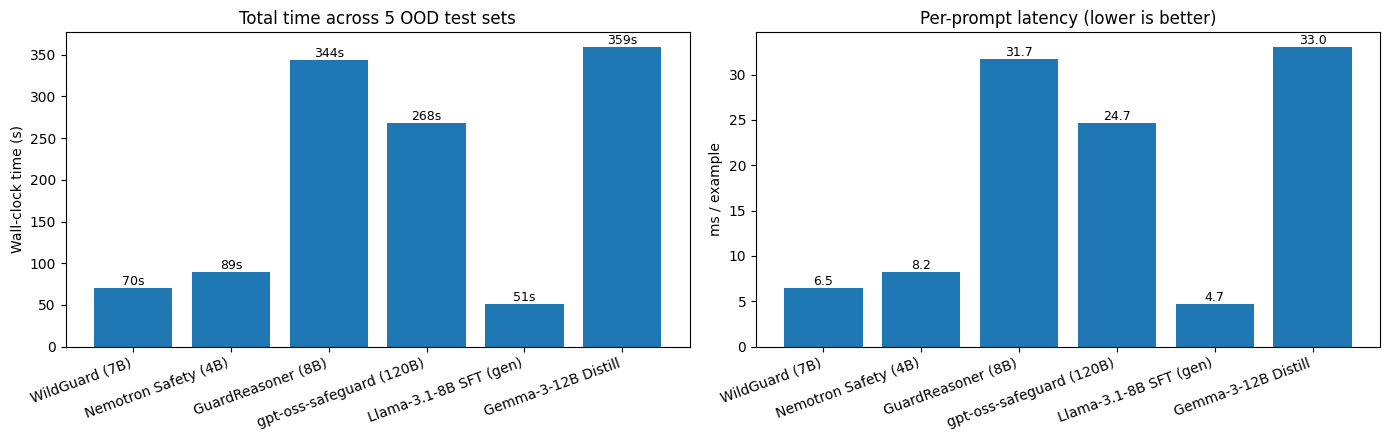

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: total wall-clock for the OOD suite
bars = axes[0].bar(suite['model'], suite['elapsed_s'])
axes[0].set_ylabel('Wall-clock time (s)')
axes[0].set_title('Total time across 5 OOD test sets')
axes[0].tick_params(axis='x', rotation=20)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')
for b, v in zip(bars, suite['elapsed_s']):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f'{v:.0f}s', ha='center', va='bottom', fontsize=9)

# Right: ms/example — the honest per-prompt latency (output-length agnostic)
bars = axes[1].bar(suite['model'], suite['ms_per_example'])
axes[1].set_ylabel('ms / example')
axes[1].set_title('Per-prompt latency (lower is better)')
axes[1].tick_params(axis='x', rotation=20)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')
for b, v in zip(bars, suite['ms_per_example']):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Tokens generated

Classification models (WildGuard, Nemotron) emit a single label token. Generation/reasoning models emit reasoning and structured output, so the per-example token count climbs sharply.

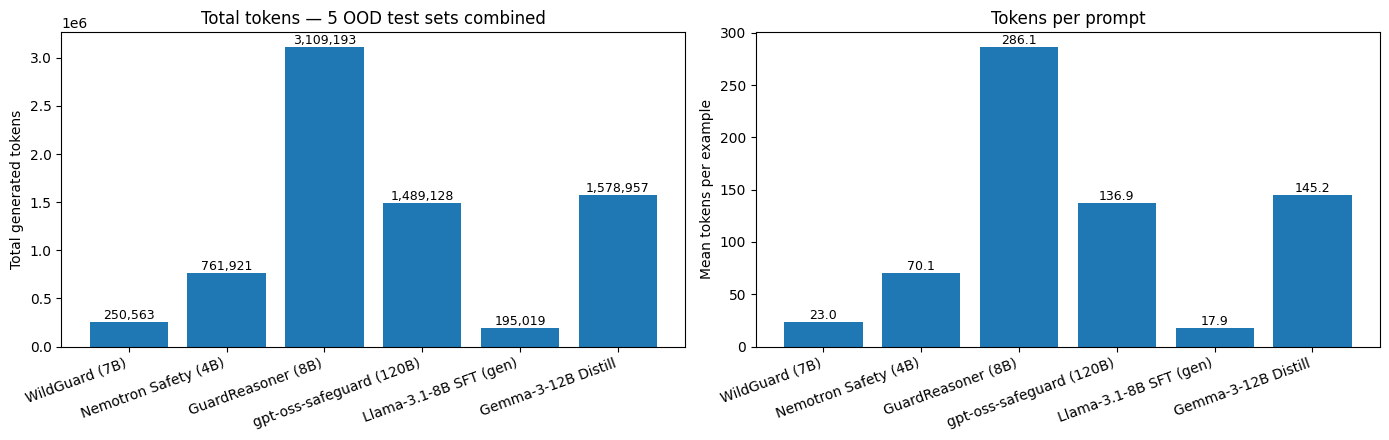

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(suite['model'], suite['total_tokens'])
axes[0].set_ylabel('Total generated tokens')
axes[0].set_title('Total tokens — 5 OOD test sets combined')
axes[0].tick_params(axis='x', rotation=20)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')
for x, v in enumerate(suite['total_tokens']):
    axes[0].text(x, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

axes[1].bar(suite['model'], suite['tokens_per_example'])
axes[1].set_ylabel('Mean tokens per example')
axes[1].set_title('Tokens per prompt')
axes[1].tick_params(axis='x', rotation=20)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')
for x, v in enumerate(suite['tokens_per_example']):
    axes[1].text(x, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Per-dataset breakdown

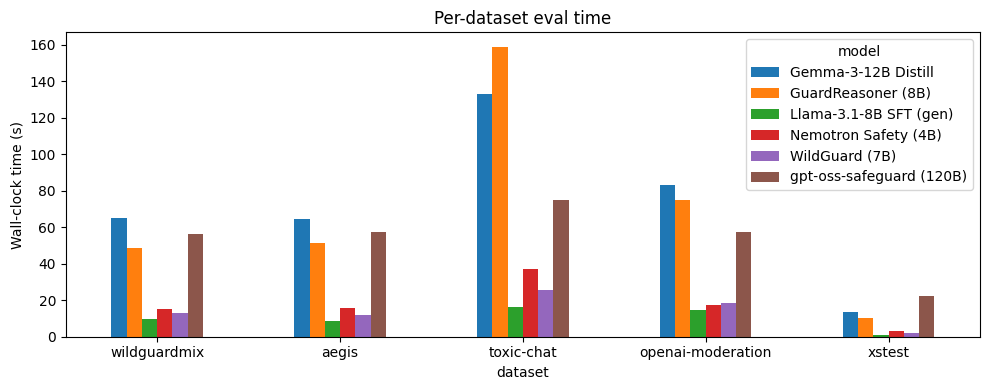

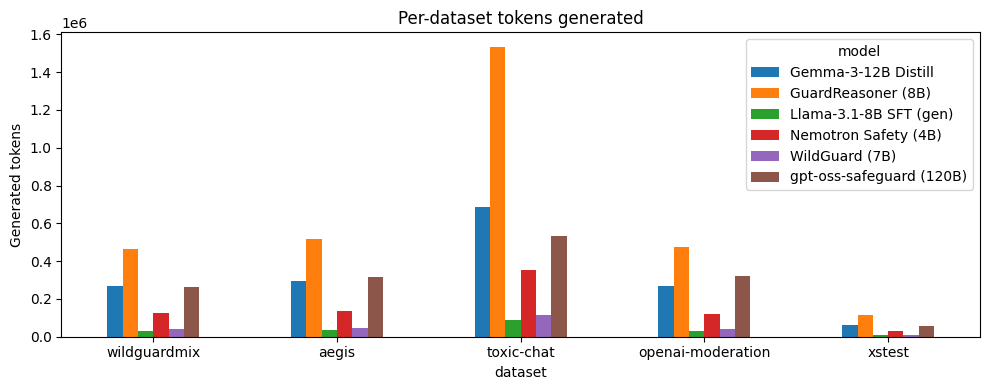

In [5]:
pivot_time = per_ds.pivot(index='dataset', columns='model', values='elapsed_s').reindex(OOD_DATASETS)
ax = pivot_time.plot.bar(figsize=(10, 4))
ax.set_ylabel('Wall-clock time (s)')
ax.set_title('Per-dataset eval time')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot_tokens = per_ds.pivot(index='dataset', columns='model', values='total_tokens').reindex(OOD_DATASETS)
ax = pivot_tokens.plot.bar(figsize=(10, 4))
ax.set_ylabel('Generated tokens')
ax.set_title('Per-dataset tokens generated')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Numeric table for the paper

In [6]:
display_suite = suite[['model', 'kind', 'total_examples', 'total_tokens',
                       'tokens_per_example', 'elapsed_s', 'ms_per_example',
                       'examples_per_second', 'tokens_per_second']].copy()
display_suite.columns = ['Model', 'Output kind', 'N examples', 'Tokens',
                         'Tokens/example', 'Time (s)', 'ms/example',
                         'Examples/s', 'Throughput (tok/s)']
display_suite.round({'Tokens/example': 1, 'Time (s)': 1,
                     'ms/example': 2, 'Examples/s': 1,
                     'Throughput (tok/s)': 1})

,Model,Output kind,N examples,Tokens,Tokens/example,Time (s),ms/example,Examples/s,Throughput (tok/s)
0,WildGuard (7B),classification,10874,250563,23.0,70.3,6.46,154.7,3565.1
1,Nemotron Safety (4B),classification (reasoning),10876,761921,70.1,89.2,8.20,122.0,8545.3
2,GuardReasoner (8B),classification (reasoning),10866,3109193,286.1,344.1,31.66,31.6,9036.8
3,gpt-oss-safeguard (120B),classification (reasoning),10876,1489128,136.9,268.2,24.66,40.6,5552.9
4,Llama-3.1-8B SFT (gen),generation,10874,195019,17.9,50.7,4.66,214.4,3844.8
5,Gemma-3-12B Distill,reasoning + human_intent,10876,1578957,145.2,359.0,33.01,30.3,4398.2
